In [1]:
import pandas as pd

In [2]:
# Load the SMS Spam Collection dataset into a pandas DataFrame
# We must specify encoding='latin-1' to handle the non-standard characters present in this specific text file
df=pd.read_csv('spam.csv',encoding='latin-1')

In [3]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


### Initial Data Cleaning

In [4]:
# Isolate the target (v1) and the feature (v2) columns, dropping the unnamed NaN columns
df=df[['v1','v2']]
# Rename columns
df.columns=['label','message']

In [5]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Checking for missing values and duplicates

In [6]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(403)

#### Dropping Duplicates and Checking Class Balance

In [8]:
df=df.drop_duplicates(keep='first')

df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

#### Lowercasing massage column

In [9]:
df.loc[:,'message']=df['message'].str.lower()

#### Removing Punctuaion

In [10]:
import re
# Use regular expressions to remove all punctuation
# r'[^\w\s]' matches anything that is NOT an alphanumeric character (\w) or whitespace (\s)

# re.sub(pattern, replacement, text)
# This is a regex function that means: "search through text, find anything matching pattern, 
# and replace each match with replacement.

df['message']=df['message'].apply(lambda x: re.sub(r'[^\w\s]','',x))
# .apply() looks at df['message'], and goes row by row
# For each row, it takes that row's text value and temporarily calls it x
# It runs re.sub(r'[^\w\s]', '', x) — using that row's specific text as x
# It collects the return value of that expression for every row
# Puts all those results back together into a new column

In [11]:
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


#### Tokenization
* Machine learning models cannot read continuous sentences; they need text broken down into smaller, discrete units. Tokenization is the process of splitting a continuous string of text into a list of individual words (or tokens).

For example, the message `"win free tickets"` becomes the list `['win', 'free', 'tickets']`.

We will use the Natural Language Toolkit `(nltk)` library to tokenize our messages, transforming each string into a structured list of words that our algorithms can eventually count and analyze.

In [12]:
import nltk
from nltk.tokenize import word_tokenize
# Apply the word_tokenize function to split each message into a list of individual words
df['tokens']=df['message'].apply(word_tokenize)
# Display tokens
print(df[['message','tokens']].head())

                                             message  \
0  go until jurong point crazy available only in ...   
1                            ok lar joking wif u oni   
2  free entry in 2 a wkly comp to win fa cup fina...   
3        u dun say so early hor u c already then say   
4  nah i dont think he goes to usf he lives aroun...   

                                              tokens  
0  [go, until, jurong, point, crazy, available, o...  
1                     [ok, lar, joking, wif, u, oni]  
2  [free, entry, in, 2, a, wkly, comp, to, win, f...  
3  [u, dun, say, so, early, hor, u, c, already, t...  
4  [nah, i, dont, think, he, goes, to, usf, he, l...  


#### Removing Stopwords
* Stopwords are very common words like `"the", "is", "in", and "and"`. While essential for human grammar, they carry almost no predictive value for determining if a message is spam. By filtering out these words, we reduce noise and help the model focus entirely on the meaningful keywords in the text.

In [13]:
from nltk.corpus import stopwords

# store the English stopwords in a set for faster preprocessing
stop_words=set(stopwords.words('english'))

# Apply a filter to keep only the tokens that are not in stop_words
df['tokens']=df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])
print(df['tokens'])

0       [go, jurong, point, crazy, available, bugis, n...
1                          [ok, lar, joking, wif, u, oni]
2       [free, entry, 2, wkly, comp, win, fa, cup, fin...
3           [u, dun, say, early, hor, u, c, already, say]
4       [nah, dont, think, goes, usf, lives, around, t...
                              ...                        
5567    [2nd, time, tried, 2, contact, u, u, å750, pou...
5568                  [ì_, b, going, esplanade, fr, home]
5569                     [pity, mood, soany, suggestions]
5570    [guy, bitching, acted, like, id, interested, b...
5571                                   [rofl, true, name]
Name: tokens, Length: 5169, dtype: object


#### Stemming vs. Lemmatization
In natural language processing, words often appear in multiple grammatical forms `(e.g., "run", "running", "ran")`. To help our machine learning model recognize that these variations represent the exact same underlying concept, we reduce words back to their base form. There are two primary techniques for this:

* `Stemming`: This is a fast, rule-based approach that simply chops off the ends of words using rigid rules. For example, "caring" becomes "car", and "history" becomes "hist". While quick, it often results in incomplete non-words.

* `Lemmatization`: This is a smarter, dictionary-based approach. It analyzes the word's structure and context to return its proper linguistic root (called the "lemma"). For example, "caring" becomes "care", and "better" becomes "good".

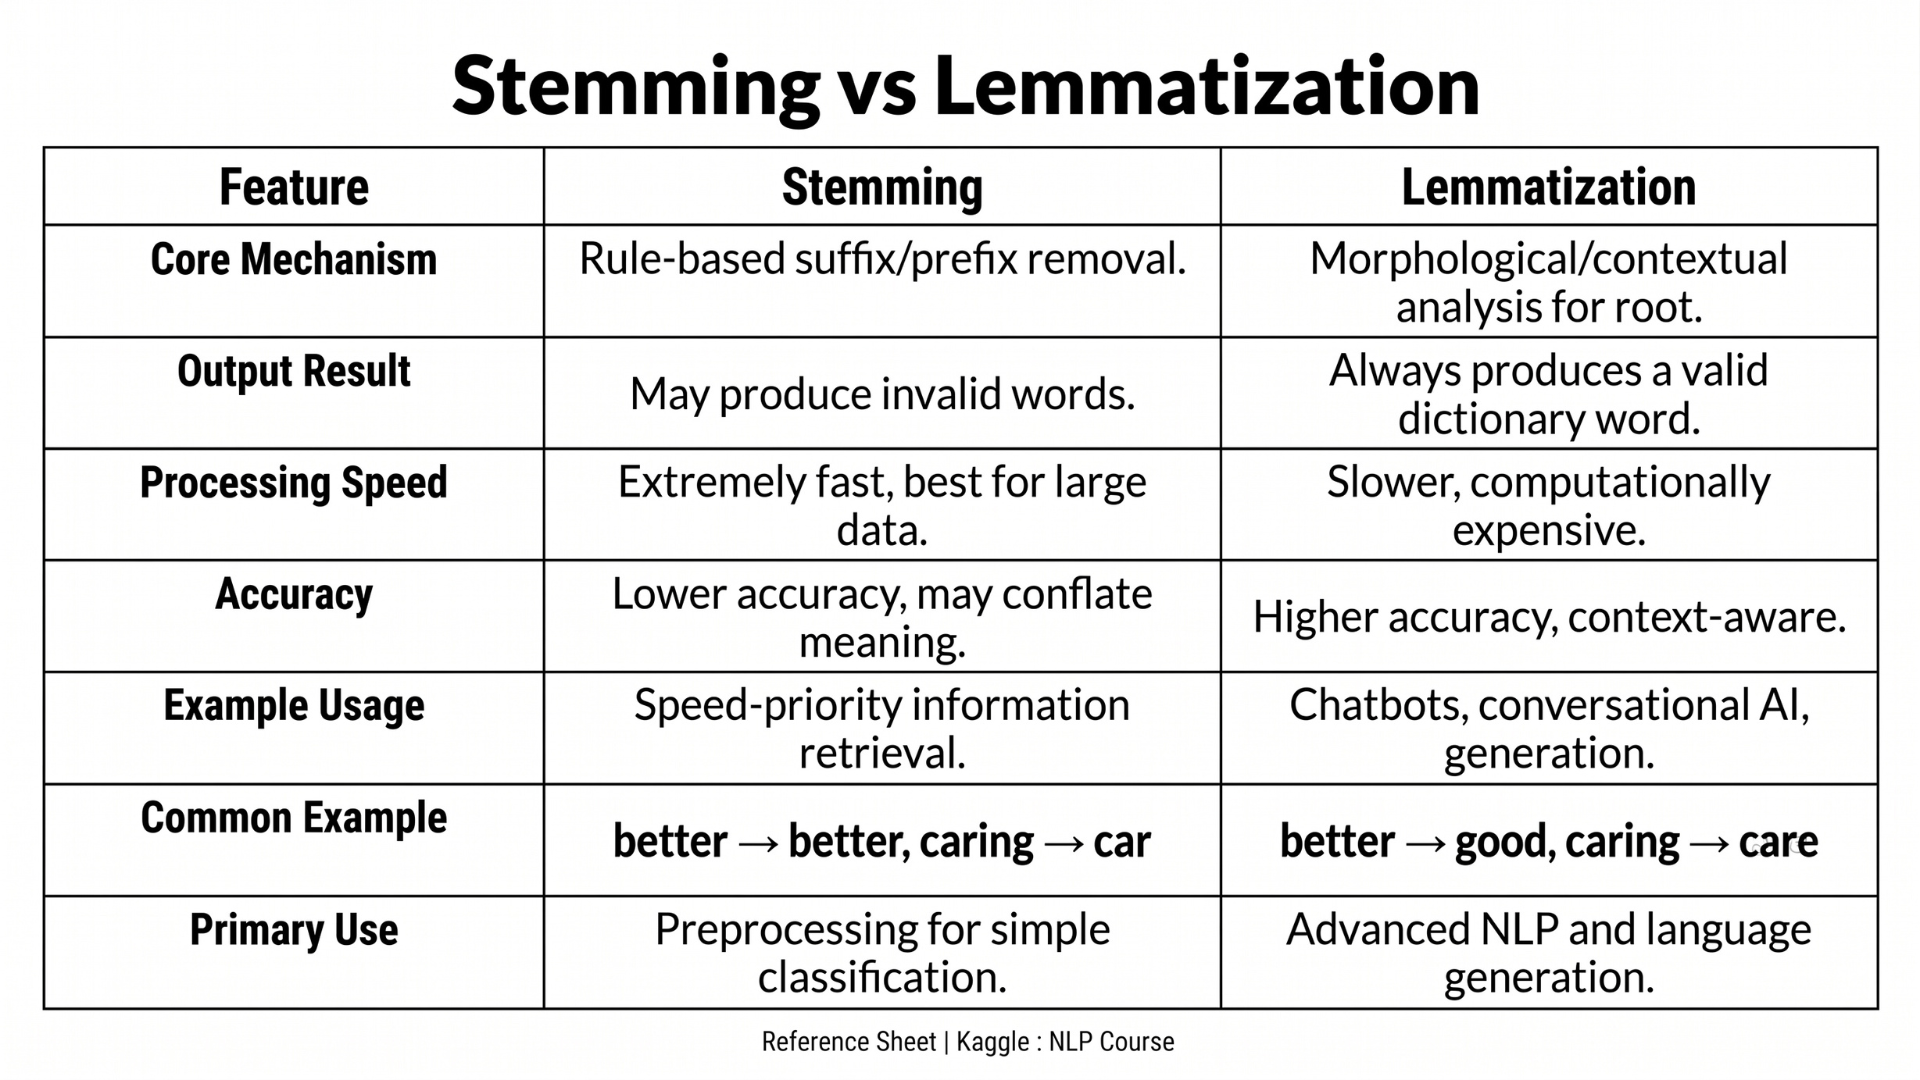

For this fast, beginner-friendly spam filter, we will proceed with Stemming. While it might leave us with some funny-looking root words `(like turning "crazy" into "crazi")`, our machine learning model doesn't need perfect English. It just needs consistent patterns.

In [14]:
# Stemming
from nltk.stem import PorterStemmer
ps=PorterStemmer()

# Apply the stemmer to chop off prefixes/suffixes and find the root stem
df['tokens']=df['tokens'].apply(lambda x: [ps.stem(word) for word in x])

print(df['tokens'])

0       [go, jurong, point, crazi, avail, bugi, n, gre...
1                            [ok, lar, joke, wif, u, oni]
2       [free, entri, 2, wkli, comp, win, fa, cup, fin...
3           [u, dun, say, earli, hor, u, c, alreadi, say]
4       [nah, dont, think, goe, usf, live, around, tho...
                              ...                        
5567    [2nd, time, tri, 2, contact, u, u, å750, pound...
5568                      [ì_, b, go, esplanad, fr, home]
5569                         [piti, mood, soani, suggest]
5570    [guy, bitch, act, like, id, interest, buy, som...
5571                                   [rofl, true, name]
Name: tokens, Length: 5169, dtype: object


#### Rejoining tokens into text
Our final step in this notebook is to stitch these cleaned tokens back together into a single, clean sentence. We will use Python's `.join()` function to combine the words, separated by a single space.

In [15]:
df['processed_message']=df['tokens'].apply(lambda x: ' '.join(x))
df[['tokens','processed_message']].head()

,tokens,processed_message
0,"[go, jurong, point, crazi, avail, bugi, n, gre...",go jurong point crazi avail bugi n great world...
1,"[ok, lar, joke, wif, u, oni]",ok lar joke wif u oni
2,"[free, entri, 2, wkli, comp, win, fa, cup, fin...",free entri 2 wkli comp win fa cup final tkt 21...
3,"[u, dun, say, earli, hor, u, c, alreadi, say]",u dun say earli hor u c alreadi say
4,"[nah, dont, think, goe, usf, live, around, tho...",nah dont think goe usf live around though


In [16]:
# --- SAVE THE CLEANED DATA ---

df.to_csv('cleaned_spam_data.csv', index=False)

print("Cleaned data saved as 'cleaned_spam_data.csv'")

Cleaned data saved as 'cleaned_spam_data.csv'
